In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from dotenv import load_dotenv

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

load_dotenv()

True

In [7]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [8]:
MAX_TOKENS=150

In [9]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]


def get_response(state: ChatState):

    messages = trim_messages(
        state['messages'],
        strategy='last',
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print(f"Current Token Count ---> {count_tokens_approximately(messages=messages)}")

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {'messages': [response]}

In [ ]:
builder = StateGraph(ChatState)
builder.add_node('response', get_response)
builder.add_edge(START, 'response')

In [14]:
cp = InMemorySaver()
chatbot = builder.compile(checkpointer=cp)

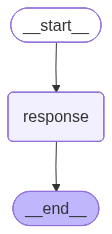

In [15]:
chatbot

In [23]:
import uuid

def get_thread_id()-> str:
    return str(uuid.uuid4())

CONFIG={'configurable':{'thread_id':get_thread_id()}}

In [25]:
result = chatbot.invoke(
    {'messages':[{"role":"user", "content": "Hello, I am Rancho, A White House Cat."}]},
    config=CONFIG
)

result['messages'][-1].content

Current Token Count ---> 14
Hello, I am Rancho, A White House Cat.


'Hello Rancho! 🐾 It’s a pleasure to meet the famous White House cat. How are you doing today? Any fun stories from the West Wing you’d like to share? 😺'

In [ ]:
result = chatbot.invoke(
    {'messages':[{"role":"user", "content": "I am just hungry everytime, want to eat more and more anytime."}]},
    config=CONFIG
)

result['messages'][-1].content

Current Token Count ---> 77
Hello, I am Rancho, A White House Cat.
Hello Rancho! 🐾 It’s a pleasure to meet the famous White House cat. How are you doing today? Any fun stories from the West Wing you’d like to share? 😺
I am just hungry everytime, want to eat more and more anytime.


'Hey there, Rancho! 😺  \nSounds like you’ve got a serious case of the “always‑hungry” vibes. Here are a few cat‑friendly tips to help satisfy those cravings while keeping you feeling purr‑fectly healthy:\n\n---\n\n### 1. **Pick the Right Food**\n| Type | What it does | Why cats love it |\n|------|--------------|------------------|\n| **Wet (canned) food** | High moisture, tasty protein | Mimics the texture of fresh prey; helps keep you hydrated |\n| **Dry kibble** | Crunchy, long‑lasting | Good for dental health (if the kibble is designed for that) |\n| **Raw or “fresh‑freeze” meals** | Natural meat, minimal processing | Closest to what wild cats eat (but make sure it’s balanced and safe) |\n\n**Tip:** A mix of wet and dry usually hits the sweet spot—wet for flavor & moisture, dry for crunch and longer satiety.\n\n---\n\n### 2. **Spread Out the Meals**\n- **Small, frequent meals** (e.g., 3‑4 times a day) can keep a cat’s metabolism steady and reduce that “I’m starving!” feeling.\n- If 

In [ ]:
result = chatbot.invoke(
    {'messages':[{"role":"user", "content": "My older brother was chonkie earlier, but he seems bit low, his mouth looks bit small too. Why?"}]},
    config=CONFIG
)

result['messages'][-1].content

Current Token Count ---> 28
My older brother was chonkie earlier, but he seems bit low, his mouth looks bit small too. Why?


'I’m sorry you’re noticing those changes in your brother—it can be unsettling when a loved one’s appearance shifts suddenly. While I can’t give a definitive diagnosis (and it’s always best to have a healthcare professional evaluate him in person), here are some common reasons why someone might go from looking “chonkie” (i.e., fuller or a bit heavier) to appearing thinner, with a smaller‑looking mouth or “low” facial tone:\n\n| Possible cause | How it might look | Typical accompanying signs |\n|----------------|-------------------|----------------------------|\n| **Rapid weight loss** (diet, illness, stress) | Cheeks and jawline become more hollow; the mouth may look smaller because there’s less soft‑tissue padding. | Fatigue, hunger, changes in appetite, dizziness, or a recent change in eating habits. |\n| **Dehydration** | Skin loses its plumpness, making the face look sunken and the mouth appear tighter. | Dry mouth, dark urine, thirst, reduced skin turgor, headaches. |\n| **Fluid lo

In [31]:
result['messages'][-1].content.split('\n')

['I’m sorry you’re noticing those changes in your brother—it can be unsettling when a loved one’s appearance shifts suddenly. While I can’t give a definitive diagnosis (and it’s always best to have a healthcare professional evaluate him in person), here are some common reasons why someone might go from looking “chonkie” (i.e., fuller or a bit heavier) to appearing thinner, with a smaller‑looking mouth or “low” facial tone:',
 '',
 '| Possible cause | How it might look | Typical accompanying signs |',
 '|----------------|-------------------|----------------------------|',
 '| **Rapid weight loss** (diet, illness, stress) | Cheeks and jawline become more hollow; the mouth may look smaller because there’s less soft‑tissue padding. | Fatigue, hunger, changes in appetite, dizziness, or a recent change in eating habits. |',
 '| **Dehydration** | Skin loses its plumpness, making the face look sunken and the mouth appear tighter. | Dry mouth, dark urine, thirst, reduced skin turgor, headaches.

In [32]:
result = chatbot.invoke(
    {'messages':[{"role":"user", "content": "What is my name, do you remember me?"}]},
    config=CONFIG
)

result['messages'][-1].content.split('\n')

Current Token Count ---> 13
What is my name, do you remember me?


['I don’t have any record of your name from our previous conversation. If you’d like me to address you by name, just let me know what it is!']